[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module2/2_A_FirstLook_atNN_with_MNIST_images.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS (invisible when rendered - double-click to read):
Video 16 (M2.3) - MNIST: a dense network reads handwriting

- The history hook: LeNet at Bell Labs reading zip codes for the Post Office - one of deep learning's first real wins. 28x28 centered digits.
- The move that makes it work: FLATTEN 28x28 into a 784-long row; scale pixels by /255 (there's the M1 scaling habit again).
- Dense(784)->10 softmax, to_categorical labels, categorical_crossentropy -> ~98% in 15 epochs.
- Plant the Module 3 flag: this net memorizes PIXEL POSITIONS - shift the digit off-center and it falls apart. ConvNets fix exactly that.
- If running long, split at Evaluate The Model (cell ~38).
-->

# A First Look at a NN with MNIST images
------------------------------
**Dr. Dave Wanik**

This notebook contains the code samples found in Chapter 2, Section 1 of [Deep Learning with Python](https://www.manning.com/books/deep-learning-with-python?a_aid=keras&a_bid=76564dff). Note that the original text features far more content, in particular further explanations and figures: in this notebook, you will only find source code and related comments.

----

We will now take a look at a first concrete example of a neural network, which makes use of the Python library Keras to learn to classify
hand-written digits. Unless you already have experience with Keras or similar libraries, you will not understand everything about this
first example right away. You probably haven't even installed Keras yet. Don't worry, that is perfectly fine. In the next chapter, we will
review each element in our example and explain them in detail. So don't worry if some steps seem arbitrary or look like magic to you!
We've got to start somewhere.

The problem we are trying to solve here is to classify grayscale images of handwritten digits (28 pixels by 28 pixels), into their 10
categories (0 to 9). The dataset we will use is the MNIST dataset, a classic dataset in the machine learning community, which has been
around for almost as long as the field itself and has been very intensively studied. It's a set of 60,000 training images, plus 10,000 test
images, assembled by the National Institute of Standards and Technology (the NIST in MNIST) in the 1980s. You can think of "solving" MNIST
as the "Hello World" of deep learning -- it's what you do to verify that your algorithms are working as expected. As you become a machine
learning practitioner, you will see MNIST come up over and over again, in scientific papers, blog posts, and so on.

The MNIST dataset comes pre-loaded in Keras, in the form of a set of four Numpy arrays:

In [1]:
from keras.datasets import mnist

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

`train_images` and `train_labels` form the "training set", the data that the model will learn from. The model will then be tested on the
"test set", `test_images` and `test_labels`. Our images are encoded as Numpy arrays, and the labels are simply an array of digits, ranging
from 0 to 9. There is a one-to-one correspondence between the images and the labels.

Let's have a look at the training data:

In [2]:
train_images.shape

(60000, 28, 28)

In [3]:
len(train_labels)

60000

In [4]:
train_labels

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [5]:
tmp = train_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

## Look at one image...
Just to get a feel for the data.

In [6]:
# look at one image
import pandas as pd
import numpy as np
import sys

# subset first 'image'
x = train_images[0]
# convert to pandas dataframe for easy viewing...
x = pd.DataFrame(x)
print(x.shape) # 28 rows and 28 columns
# you can confirm
print(train_labels[0])
x # it's the number 5!



(28, 28)
5


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


Let's have a look at the test data:

In [7]:
test_images.shape

(10000, 28, 28)

In [8]:
len(test_labels)

10000

In [9]:
test_labels[0:10] # just a sample of them

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [10]:
# check out value counts
tmp = test_labels
import pandas as pd
tmp = pd.DataFrame(tmp)
tmp[0].value_counts()

0
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64

### So what score do we have to beat?

Remember the Titanic... before we fit anything, we asked what the LAZIEST possible model would score. Always ask that question!

Look at those counts. Ten digits, and they're spread pretty evenly - every class is somewhere between **8.9% and 11.4%** of the test set. So a "model" that ignores the image completely and always guesses the most common digit (that's a **1**, at 11.35%) scores about **11%**. Call it **10%** - that's the number to beat, because with ten balanced classes, random guessing is 1-in-10.

That's a MUCH lower bar than the Titanic's 62%... and that's the whole point. **The baseline isn't always 50%, and it isn't always high - it's whatever the do-nothing model gets on YOUR data.** When our network comes back at 98%, hold it up against 10% and you'll see just how much those weights actually learned.

In [11]:
# making a copy for later (logistic regression)
copy_train_labels = train_labels
copy_test_labels = test_labels

Our workflow will be as follow: first we will present our neural network with the training data, `train_images` and `train_labels`. The
network will then learn to associate images and labels. Finally, we will ask the network to produce predictions for `test_images`, and we
will verify if these predictions match the labels from `test_labels`.

Let's build our network -- again, remember that you aren't supposed to understand everything about this example just yet.

In [12]:
28*28

784

In [13]:
from keras import models
from keras import layers
from keras.layers import Dense

network = models.Sequential()
network.add(Dense(784, activation='relu', input_shape=(28 * 28,))) # (features, )
network.add(Dense(10, activation='softmax'))
network.summary()

# note: input shape is the trickiest part IMHO...
# think of it as (number of columns, number of samples)
# number of samples is ALWAYS left blank (you'll set the batch size later on!)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,290 (2.38 MB)

 Trainable params: 623,290 (2.38 MB)

 Non-trainable params: 0 (0.00 B)


The core building block of neural networks is the "layer", a data-processing module which you can conceive as a "filter" for data. Some
data comes in, and comes out in a more useful form. Precisely, layers extract _representations_ out of the data fed into them -- hopefully
representations that are more meaningful for the problem at hand. Most of deep learning really consists of chaining together simple layers
which will implement a form of progressive "data distillation". A deep learning model is like a sieve for data processing, made of a
succession of increasingly refined data filters -- the "layers".

Here our network consists of a sequence of two `Dense` layers, which are densely-connected (also called "fully-connected") neural layers.
The second (and last) layer is a 10-way "softmax" layer, which means it will return an array of 10 probability scores (summing to 1). Each
score will be the probability that the current digit image belongs to one of our 10 digit classes.

To make our network ready for training, we need to pick three more things, as part of "compilation" step:

* A loss function: the is how the network will be able to measure how good a job it is doing on its training data, and thus how it will be
able to steer itself in the right direction.
* An optimizer: this is the mechanism through which the network will update itself based on the data it sees and its loss function.
* Metrics to monitor during training and testing. Here we will only care about accuracy (the fraction of the images that were correctly
classified).

The exact purpose of the loss function and the optimizer will be made clear throughout the next two chapters.

In [14]:
network.compile(optimizer='rmsprop', # you could use rmsprop or Adam - both are good!
                loss='categorical_crossentropy', # many categories - you need to use 'categorical_crossentropy' and NOT 'binary_crossentropy'
                metrics=['accuracy'])


Before training, we will preprocess our data by reshaping it into the shape that the network expects, and scaling it so that all values are in
the `[0, 1]` interval. Previously, our training images for instance were stored in an array of shape `(60000, 28, 28)` of type `uint8` with
values in the `[0, 255]` interval. We transform it into a `float32` array of shape `(60000, 28 * 28)` with values between 0 and 1.

In [15]:
28*28

784

In [16]:
train_images = train_images.reshape((60000, 28 * 28)) # 60K rows, with 784 columns... wow!
train_images = train_images.astype('float32') / 255 # here we are scaling by max pixel value (where white =255, black = 0)

test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

In [17]:
# BE CURIOUS!
# see what the model did
x = train_images[0] # instead of a 2D array that is 28*28, it's a single row!
x

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [18]:
# you can see this in the entire dataset too
x = pd.DataFrame(train_images)
print(x.shape)
print(28*28) # see how the shape matches up?
x.head(n=10)

# that first sample is now just the first row

(60000, 784)
784


,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We also need to categorically encode the labels, a step which we explain in chapter 3:

In [19]:
# from keras.utils import to_categorical # this is the old code!
from tensorflow.keras.utils import to_categorical  # this is the new way!

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [20]:
# BE CURIOUS! See what it looks like
x = train_labels[0]
print(x)
# check out the output - the first sample

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [21]:
# check them ALL out!
x = train_labels
x = pd.DataFrame(x)
x

# so the labels are in an ARRAY with one column for each potential outcome.

,0,1,2,3,4,5,6,7,8,9
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
59995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
59996,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
59997,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
59998,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


We are now ready to train our network, which in Keras is done via a call to the `fit` method of the network:
we "fit" the model to its training data.

In [22]:
history = network.fit(train_images, train_labels, epochs=15, batch_size=128, validation_split=0.2, shuffle=True)

Epoch 1/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 4:31 725ms/step - accuracy: 0.1406 - loss: 2.3471

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5972 - loss: 1.3766    

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7127 - loss: 1.0151

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7662 - loss: 0.8399

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7975 - loss: 0.7350

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8146 - loss: 0.6729

 53/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8295 - loss: 0.6169

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8409 - loss: 0.5757

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8494 - loss: 0.5408

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8539 - loss: 0.5253

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8574 - loss: 0.5095

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8618 - loss: 0.4948

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8653 - loss: 0.4828

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8685 - loss: 0.4697

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8712 - loss: 0.4595

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8742 - loss: 0.4474

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8766 - loss: 0.4376

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8791 - loss: 0.4275

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8817 - loss: 0.4178

150/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8836 - loss: 0.4096

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8857 - loss: 0.4016

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8875 - loss: 0.3954

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8894 - loss: 0.3878

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8908 - loss: 0.3821

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8924 - loss: 0.3760

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8941 - loss: 0.3701

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8960 - loss: 0.3634

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8972 - loss: 0.3587

215/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8992 - loss: 0.3529

223/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9007 - loss: 0.3473

230/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9017 - loss: 0.3438

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9025 - loss: 0.3409

244/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9037 - loss: 0.3366

251/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9045 - loss: 0.3335

258/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9058 - loss: 0.3288

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9067 - loss: 0.3253

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9078 - loss: 0.3213

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9087 - loss: 0.3177

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9098 - loss: 0.3133

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9108 - loss: 0.3092

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9116 - loss: 0.3060

310/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9124 - loss: 0.3029

318/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9139 - loss: 0.2990

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9146 - loss: 0.2964

333/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9154 - loss: 0.2936

341/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9161 - loss: 0.2904

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9172 - loss: 0.2872

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9179 - loss: 0.2842

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9187 - loss: 0.2814

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9195 - loss: 0.2789

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9197 - loss: 0.2777 - val_accuracy: 0.9620 - val_loss: 0.1349


Epoch 2/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.9375 - loss: 0.1381

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9592 - loss: 0.1281  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9619 - loss: 0.1178

 26/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9591 - loss: 0.1229

 34/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9596 - loss: 0.1236

 42/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9598 - loss: 0.1290

 50/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9597 - loss: 0.1301

 58/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9604 - loss: 0.1277

 66/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9611 - loss: 0.1264

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9613 - loss: 0.1249

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9605 - loss: 0.1275

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9613 - loss: 0.1254

 98/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9620 - loss: 0.1243

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9627 - loss: 0.1231

114/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9620 - loss: 0.1244

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9621 - loss: 0.1237

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9621 - loss: 0.1228

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9623 - loss: 0.1223

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9629 - loss: 0.1205

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9633 - loss: 0.1199

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9634 - loss: 0.1192

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9636 - loss: 0.1195

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9636 - loss: 0.1197

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9637 - loss: 0.1196

195/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9643 - loss: 0.1179

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9643 - loss: 0.1177

211/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9643 - loss: 0.1175

218/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9647 - loss: 0.1167

225/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9650 - loss: 0.1164

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9653 - loss: 0.1161

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9657 - loss: 0.1153

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9656 - loss: 0.1153

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9660 - loss: 0.1145

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9662 - loss: 0.1138

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9665 - loss: 0.1128

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9666 - loss: 0.1126

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9666 - loss: 0.1124

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9665 - loss: 0.1125

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.1119

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9666 - loss: 0.1122

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9667 - loss: 0.1117

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9668 - loss: 0.1111

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9669 - loss: 0.1107

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9670 - loss: 0.1104

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1101

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9671 - loss: 0.1101

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9673 - loss: 0.1096

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9675 - loss: 0.1096

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9675 - loss: 0.1096 - val_accuracy: 0.9712 - val_loss: 0.1013


Epoch 3/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.9844 - loss: 0.0791

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9809 - loss: 0.0721  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9784 - loss: 0.0785

 25/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9775 - loss: 0.0816

 33/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9792 - loss: 0.0761

 40/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9799 - loss: 0.0731

 48/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9780 - loss: 0.0763

 56/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9788 - loss: 0.0749

 64/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9799 - loss: 0.0735

 72/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9803 - loss: 0.0708

 80/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0700

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9798 - loss: 0.0713

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9794 - loss: 0.0722

104/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9799 - loss: 0.0711

112/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9801 - loss: 0.0705

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0694

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0693

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9802 - loss: 0.0711

144/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9805 - loss: 0.0708

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9801 - loss: 0.0713

160/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9801 - loss: 0.0708

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9803 - loss: 0.0708

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9805 - loss: 0.0706

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0706

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0705

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0700

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9804 - loss: 0.0698

215/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9807 - loss: 0.0692

223/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9805 - loss: 0.0701

231/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9800 - loss: 0.0717

239/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0715

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0712

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9802 - loss: 0.0708

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0712

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9800 - loss: 0.0711

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0708

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0709

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0707

281/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0706

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9801 - loss: 0.0704

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9801 - loss: 0.0705

298/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0704

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9801 - loss: 0.0702

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0704

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0703

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9799 - loss: 0.0704

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9798 - loss: 0.0705

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9798 - loss: 0.0705

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9798 - loss: 0.0702

346/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9797 - loss: 0.0699

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9798 - loss: 0.0701

358/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9796 - loss: 0.0701

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9797 - loss: 0.0698

369/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9797 - loss: 0.0700

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9796 - loss: 0.0703

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9795 - loss: 0.0705 - val_accuracy: 0.9764 - val_loss: 0.0807


Epoch 4/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.9844 - loss: 0.0761

  6/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9883 - loss: 0.0462 

  9/375 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9896 - loss: 0.0393

 15/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9896 - loss: 0.0375

 21/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9892 - loss: 0.0386

 26/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9889 - loss: 0.0413

 31/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9877 - loss: 0.0441

 36/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9887 - loss: 0.0425

 42/375 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9885 - loss: 0.0422

 48/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9876 - loss: 0.0451

 54/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9870 - loss: 0.0457

 60/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9867 - loss: 0.0458

 66/375 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9871 - loss: 0.0447

 72/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9872 - loss: 0.0442

 78/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9873 - loss: 0.0447

 84/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9870 - loss: 0.0453

 91/375 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9870 - loss: 0.0449

 97/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9866 - loss: 0.0459 

103/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9863 - loss: 0.0465

108/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9857 - loss: 0.0482

114/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9858 - loss: 0.0487

120/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9855 - loss: 0.0495

126/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9856 - loss: 0.0491

131/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9858 - loss: 0.0485

137/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9859 - loss: 0.0480

143/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9860 - loss: 0.0475

149/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9862 - loss: 0.0468

155/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9860 - loss: 0.0476

161/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9861 - loss: 0.0471

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9858 - loss: 0.0478

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9856 - loss: 0.0480

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9856 - loss: 0.0477

183/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9857 - loss: 0.0477

188/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9857 - loss: 0.0478

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9857 - loss: 0.0481

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9857 - loss: 0.0483

207/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9859 - loss: 0.0477 

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9859 - loss: 0.0478

220/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9858 - loss: 0.0486

225/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9858 - loss: 0.0486

228/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9857 - loss: 0.0489

232/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9859 - loss: 0.0487

236/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9859 - loss: 0.0485

240/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9861 - loss: 0.0480

245/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9861 - loss: 0.0481

250/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9861 - loss: 0.0482

253/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9860 - loss: 0.0483

257/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9860 - loss: 0.0485

261/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9861 - loss: 0.0481

266/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9860 - loss: 0.0484

271/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9859 - loss: 0.0484

275/375 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9860 - loss: 0.0485

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0485

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9860 - loss: 0.0486

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9861 - loss: 0.0484

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9861 - loss: 0.0483

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9861 - loss: 0.0484

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9861 - loss: 0.0483

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9860 - loss: 0.0485

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9860 - loss: 0.0485

315/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9860 - loss: 0.0483

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0483

326/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9858 - loss: 0.0485

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0483

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0482

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9857 - loss: 0.0485

349/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9858 - loss: 0.0484

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0484

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9859 - loss: 0.0482

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9857 - loss: 0.0487

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9858 - loss: 0.0486

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9858 - loss: 0.0486 - val_accuracy: 0.9776 - val_loss: 0.0787


Epoch 5/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.9922 - loss: 0.0215

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9852 - loss: 0.0457  

 16/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9858 - loss: 0.0410

 23/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9881 - loss: 0.0356

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9883 - loss: 0.0355

 34/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9881 - loss: 0.0375

 40/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9891 - loss: 0.0349

 48/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9883 - loss: 0.0363

 56/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9880 - loss: 0.0368

 63/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9886 - loss: 0.0357

 70/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9887 - loss: 0.0354

 77/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9891 - loss: 0.0351

 84/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9898 - loss: 0.0338

 90/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9898 - loss: 0.0330

 96/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9896 - loss: 0.0336

103/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9895 - loss: 0.0337

109/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9894 - loss: 0.0338

115/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9893 - loss: 0.0345

120/375 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9893 - loss: 0.0349

125/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9896 - loss: 0.0344

131/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9897 - loss: 0.0346

135/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9898 - loss: 0.0345

140/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9898 - loss: 0.0342

146/375 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9897 - loss: 0.0341

152/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9898 - loss: 0.0342

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9898 - loss: 0.0341

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9897 - loss: 0.0343

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9897 - loss: 0.0340

175/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9897 - loss: 0.0340

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9894 - loss: 0.0346

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9893 - loss: 0.0346

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9894 - loss: 0.0347

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.0346

203/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9894 - loss: 0.0346

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9894 - loss: 0.0346

215/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.0344

221/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.0346

227/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9896 - loss: 0.0345

233/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9895 - loss: 0.0349

240/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9893 - loss: 0.0356

246/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9892 - loss: 0.0356

253/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9890 - loss: 0.0357

259/375 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9891 - loss: 0.0357

265/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0357

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0358

278/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9890 - loss: 0.0361

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9891 - loss: 0.0359

291/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9891 - loss: 0.0359

297/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9892 - loss: 0.0356

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9892 - loss: 0.0357

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9892 - loss: 0.0357

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9892 - loss: 0.0358

323/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0355

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0358

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9894 - loss: 0.0355

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0358

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0358

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9892 - loss: 0.0360

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0357

374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9893 - loss: 0.0358

375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9894 - loss: 0.0358 - val_accuracy: 0.9771 - val_loss: 0.0746


Epoch 6/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 1.0000 - loss: 0.0075

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9931 - loss: 0.0298  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9952 - loss: 0.0231

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9951 - loss: 0.0216

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9944 - loss: 0.0218

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9931 - loss: 0.0241

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9926 - loss: 0.0244

 59/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9926 - loss: 0.0246

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9928 - loss: 0.0244

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9932 - loss: 0.0236

 83/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9936 - loss: 0.0230

 91/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9936 - loss: 0.0233

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0237

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0239

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9932 - loss: 0.0238

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9929 - loss: 0.0242

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0238

138/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0237

146/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0237

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9932 - loss: 0.0236

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9930 - loss: 0.0240

170/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0236

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9931 - loss: 0.0239

186/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9929 - loss: 0.0243

194/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9930 - loss: 0.0244

201/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9930 - loss: 0.0245

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9929 - loss: 0.0248

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9929 - loss: 0.0247

223/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9929 - loss: 0.0252

231/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0250

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0249

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9930 - loss: 0.0247

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0249

261/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0248

269/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0248

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9929 - loss: 0.0248

285/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9928 - loss: 0.0253

293/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9928 - loss: 0.0251

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0252

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0250

317/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0252

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9926 - loss: 0.0251

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0249

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9928 - loss: 0.0248

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9928 - loss: 0.0246

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0248

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0252

372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9927 - loss: 0.0253

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 0.9785 - val_loss: 0.0708


Epoch 7/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.9922 - loss: 0.0316

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9983 - loss: 0.0143  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9968 - loss: 0.0167

 25/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9959 - loss: 0.0167

 33/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9957 - loss: 0.0169

 41/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9949 - loss: 0.0182

 49/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9952 - loss: 0.0174

 57/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9958 - loss: 0.0166

 65/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9957 - loss: 0.0165

 73/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9956 - loss: 0.0163

 81/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9956 - loss: 0.0167

 89/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9952 - loss: 0.0171

 97/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9951 - loss: 0.0175

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9950 - loss: 0.0180

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9950 - loss: 0.0184

121/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9951 - loss: 0.0181

129/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9950 - loss: 0.0185

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9950 - loss: 0.0183

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0184

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0182

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0183

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9949 - loss: 0.0181

177/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9949 - loss: 0.0180

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9950 - loss: 0.0180

193/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9949 - loss: 0.0179

201/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9948 - loss: 0.0181

209/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9947 - loss: 0.0181

217/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9946 - loss: 0.0185

225/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9944 - loss: 0.0190

233/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9945 - loss: 0.0190

241/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0187

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0186

257/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0186

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0188

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0188

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9946 - loss: 0.0189

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0189

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9946 - loss: 0.0192

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0190

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9945 - loss: 0.0191

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9946 - loss: 0.0190

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9946 - loss: 0.0189

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9946 - loss: 0.0188

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9947 - loss: 0.0186

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9948 - loss: 0.0185

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9949 - loss: 0.0183

366/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9949 - loss: 0.0183

373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9949 - loss: 0.0182

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9949 - loss: 0.0183 - val_accuracy: 0.9756 - val_loss: 0.0869


Epoch 8/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 21s 57ms/step - accuracy: 1.0000 - loss: 0.0145

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9974 - loss: 0.0126  

 16/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9966 - loss: 0.0143

 23/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9973 - loss: 0.0124

 30/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9977 - loss: 0.0112

 37/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9977 - loss: 0.0111

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9973 - loss: 0.0110

 52/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9974 - loss: 0.0115

 60/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9973 - loss: 0.0118

 68/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9971 - loss: 0.0123

 76/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9969 - loss: 0.0124

 84/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9972 - loss: 0.0118

 92/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9971 - loss: 0.0122

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9972 - loss: 0.0121

106/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9973 - loss: 0.0119

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9975 - loss: 0.0115

120/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9973 - loss: 0.0116

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9972 - loss: 0.0117

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9973 - loss: 0.0115

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9970 - loss: 0.0120

148/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9969 - loss: 0.0120

156/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9966 - loss: 0.0127

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9966 - loss: 0.0127

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9966 - loss: 0.0127

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9964 - loss: 0.0129

185/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9964 - loss: 0.0129

191/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9964 - loss: 0.0128

198/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9965 - loss: 0.0127

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9965 - loss: 0.0129

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9966 - loss: 0.0128

219/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9966 - loss: 0.0126

226/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9965 - loss: 0.0127

233/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9965 - loss: 0.0128

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9964 - loss: 0.0131

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0130

253/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0129

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9966 - loss: 0.0128

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9966 - loss: 0.0128

273/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0133

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9964 - loss: 0.0134

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9964 - loss: 0.0133

294/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9964 - loss: 0.0133

301/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9964 - loss: 0.0133

307/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9964 - loss: 0.0132

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9964 - loss: 0.0132

321/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9965 - loss: 0.0131

329/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0130

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0130

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0131

350/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9965 - loss: 0.0132

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0132

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9966 - loss: 0.0132

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9965 - loss: 0.0132

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.9805 - val_loss: 0.0727


Epoch 9/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 1.0000 - loss: 0.0123

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9992 - loss: 0.0067  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9996 - loss: 0.0055

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9992 - loss: 0.0064

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9987 - loss: 0.0080

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9988 - loss: 0.0077

 52/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9985 - loss: 0.0084

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9984 - loss: 0.0087

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9985 - loss: 0.0085

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9986 - loss: 0.0086

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9986 - loss: 0.0087

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9984 - loss: 0.0091

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9984 - loss: 0.0090

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9984 - loss: 0.0088

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9985 - loss: 0.0086

127/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9984 - loss: 0.0089

136/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9980 - loss: 0.0100

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9977 - loss: 0.0107

154/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9978 - loss: 0.0106

162/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0103

170/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0101

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0100

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0102

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0102

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9979 - loss: 0.0102

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9980 - loss: 0.0100

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0099

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0099

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0098

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0098

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0100

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0100

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0099

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0098

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9981 - loss: 0.0097

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9981 - loss: 0.0097

305/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0098

314/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0097

322/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9980 - loss: 0.0097

330/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0097

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0097

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9978 - loss: 0.0099

357/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0099

365/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0100

374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9979 - loss: 0.0099

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9979 - loss: 0.0099 - val_accuracy: 0.9798 - val_loss: 0.0730


Epoch 10/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 1.0000 - loss: 0.0039

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9961 - loss: 0.0108  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9979 - loss: 0.0075

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9978 - loss: 0.0075

 35/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9980 - loss: 0.0070

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9984 - loss: 0.0066

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9986 - loss: 0.0062

 59/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9985 - loss: 0.0063

 67/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9987 - loss: 0.0060

 75/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9986 - loss: 0.0061

 84/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0057

 92/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0057

101/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0055

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0058

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0056

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0055

134/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0056

142/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9990 - loss: 0.0055

150/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0056

158/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9989 - loss: 0.0055

166/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0058

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0059

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0058

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0062

196/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0061

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9987 - loss: 0.0061

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0061

220/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0060

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9988 - loss: 0.0060

235/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9988 - loss: 0.0061

242/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0061

249/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0062

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0063

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0063

266/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0063

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0064

277/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0064

283/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0064

289/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0064

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0063

302/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0063

309/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0062

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0061

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0061

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0061

339/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9988 - loss: 0.0061

347/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0063

355/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0065

363/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9986 - loss: 0.0064

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9987 - loss: 0.0064

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9986 - loss: 0.0064 - val_accuracy: 0.9794 - val_loss: 0.0784


Epoch 11/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 1.0000 - loss: 0.0018

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0026  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0022

 26/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0029

 34/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0026

 43/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0025

 51/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0024

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0030

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0035

 78/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0037

 86/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0037

 94/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0037

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0041

109/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0041

117/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0040

125/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0039

133/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0039

141/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9994 - loss: 0.0039

149/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0039

157/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0039

165/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9993 - loss: 0.0039

173/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9994 - loss: 0.0038

181/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9994 - loss: 0.0039

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0038

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9994 - loss: 0.0039

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9994 - loss: 0.0038

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0039

221/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9993 - loss: 0.0039

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0039

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0040

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0040

252/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9993 - loss: 0.0041

260/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0041

268/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0042

276/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0042

284/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0042

292/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0042

300/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0043

308/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0043

316/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0043

324/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0044

332/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0044

340/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0043

348/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0044

356/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0044

364/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0045

371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9992 - loss: 0.0044

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9804 - val_loss: 0.0781


Epoch 12/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 19s 51ms/step - accuracy: 1.0000 - loss: 0.0011

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0020  

 17/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0026

 25/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9994 - loss: 0.0027

 33/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0025

 41/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9994 - loss: 0.0027

 49/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9995 - loss: 0.0026

 57/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9996 - loss: 0.0026

 65/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9996 - loss: 0.0025

 74/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0028

 82/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0028

 90/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0027

 99/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0026

107/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0026

115/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0025

123/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0026

131/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0026

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0026

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9996 - loss: 0.0026

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9996 - loss: 0.0026

163/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9996 - loss: 0.0026

171/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9996 - loss: 0.0025

179/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0024

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0024

195/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0024

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0024

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0024

220/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9997 - loss: 0.0023

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

238/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

247/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

255/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

263/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

271/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0025

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0025

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0024

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0023

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0023

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0024

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0024

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9997 - loss: 0.0025

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0025

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0024

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9997 - loss: 0.0024 - val_accuracy: 0.9833 - val_loss: 0.0739


Epoch 13/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 1.0000 - loss: 0.0020

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0014  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 28/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0014

 44/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 52/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 60/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 68/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 76/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0014

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

119/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

128/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

137/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

145/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

153/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

161/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

169/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

178/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

187/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

195/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0013

204/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0014

212/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0014

220/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

228/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

246/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

279/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

287/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

319/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

327/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

335/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0014

343/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0015

351/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0015

359/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0016

367/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9999 - loss: 0.0016

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9999 - loss: 0.0016 - val_accuracy: 0.9816 - val_loss: 0.0800


Epoch 14/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 1.0000 - loss: 0.0014

 10/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0016  

 19/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0013

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0012

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0011

 45/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 0.0011

 54/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0011

 62/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0011

 71/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0010

 79/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0010

 88/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.9988e-04

 96/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 0.0010    

105/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.8679e-04

113/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.8069e-04

122/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.5507e-04

130/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.5363e-04

139/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.3903e-04

147/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.4489e-04

155/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.4480e-04

164/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.3060e-04

172/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.2318e-04

180/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.3215e-04

189/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.2373e-04

197/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.2905e-04

205/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.4862e-04

213/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 9.3873e-04

221/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.4179e-04

229/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.3602e-04

237/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.2720e-04

245/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.2053e-04

254/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.2202e-04

262/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.3278e-04

270/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5698e-04

278/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.6469e-04

286/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.7583e-04

295/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.7104e-04

303/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.6918e-04

311/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5996e-04

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5229e-04

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.4506e-04

337/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5834e-04

345/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5976e-04

354/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5501e-04

362/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5810e-04

370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 9.5480e-04

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 1.0000 - loss: 9.5113e-04 - val_accuracy: 0.9829 - val_loss: 0.0774


Epoch 15/15


  1/375 ━━━━━━━━━━━━━━━━━━━━ 14s 40ms/step - accuracy: 1.0000 - loss: 6.0774e-04

  9/375 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 1.0000 - loss: 5.0989e-04  

 18/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.3415e-04

 27/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.5472e-04

 36/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.0203e-04

 45/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.0132e-04

 53/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.5744e-04

 61/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 5.5634e-04

 69/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.5419e-04

 77/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.5483e-04

 85/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.7585e-04

 93/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.8557e-04

102/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 5.9255e-04

110/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.1178e-04

118/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.1082e-04

126/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.3761e-04

135/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.3933e-04

143/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.6104e-04

151/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.6166e-04

159/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.4708e-04

168/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.4395e-04

176/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.5517e-04

184/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.7242e-04

192/375 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 1.0000 - loss: 6.7294e-04

200/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 6.9763e-04

208/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 6.9814e-04

216/375 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 1.0000 - loss: 7.0115e-04

224/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.9464e-04

232/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.8445e-04

240/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.8133e-04

248/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 6.7821e-04

256/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2927e-04

264/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2286e-04

272/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2344e-04

280/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2109e-04

288/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2158e-04

296/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2456e-04

304/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.3218e-04

312/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2792e-04

320/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2240e-04

328/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2184e-04

336/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.1939e-04

344/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2162e-04

352/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2701e-04

360/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.3059e-04

368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 7.2558e-04

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 1.0000 - loss: 7.2588e-04 - val_accuracy: 0.9832 - val_loss: 0.0760


Two quantities are being displayed during training: the "loss" of the network over the training data, and the accuracy of the network over
the training data.

We quickly reach an accuracy of 0.989 (i.e. 98.9%) on the training data. Now let's check that our model performs well on the test set too:

In [23]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 1.0000 - loss: 0.0022

 23/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9837 - loss: 0.0700 

 47/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.0926

 73/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9756 - loss: 0.0889

 97/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9768 - loss: 0.0949

121/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9768 - loss: 0.0939

145/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9761 - loss: 0.0935

168/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9773 - loss: 0.0878

191/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9774 - loss: 0.0856

215/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9789 - loss: 0.0796

238/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9808 - loss: 0.0723

262/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9822 - loss: 0.0665

286/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9832 - loss: 0.0643

308/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9831 - loss: 0.0648

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9831 - loss: 0.0643


In [24]:
print('test_acc:', test_acc)

test_acc: 0.9830999970436096



Our test set accuracy turns out to be ~98% -- that's quite a bit lower than the training set accuracy.
This gap between training accuracy and test accuracy is an example of "overfitting",
the fact that machine learning models tend to perform worse on new data than on their training data.
Overfitting will be a central topic in chapter 3.

This concludes our very first example -- you just saw how we could build and a train a neural network to classify handwritten digits, in
less than 20 lines of Python code. In the next chapter, we will go in detail over every moving piece we just previewed, and clarify what is really
going on behind the scenes. You will learn about "tensors", the data-storing objects going into the network, about tensor operations, which
layers are made of, and about gradient descent, which allows our network to learn from its training examples.

## Evaluate The Model

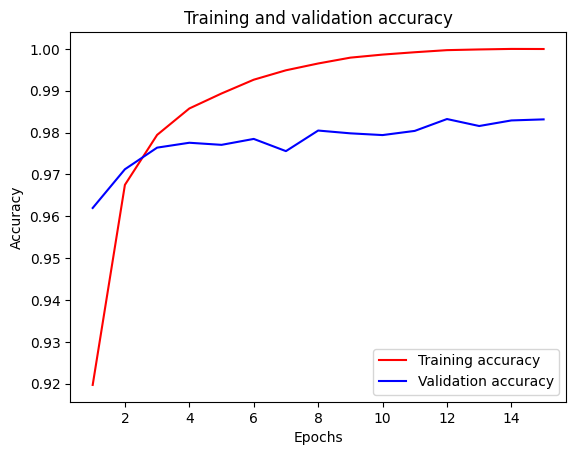

In [25]:
# show what the predictions look like for a multi-class classification problem
# pretty!

# learning curve
import matplotlib.pyplot as plt

# accuracy
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

# loss
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "r" is for "solid red line"
plt.plot(epochs, acc, 'r', label='Training accuracy')
# b is for "solid blue line"
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# see how the model did!
preds = network.predict(test_images)
preds # if you look at preds, there's actually a probability in there...

# here it is! almost a perfect prediction
# actual is left, predicted is top
# names can be found by inspecting Y
matrix = confusion_matrix(test_labels.argmax(axis=1), preds.argmax(axis=1))
matrix

  1/313 ━━━━━━━━━━━━━━━━━━━━ 16s 54ms/step

 31/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

 63/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

 95/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

127/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

160/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

191/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

223/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

254/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

287/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[ 972,    1,    1,    0,    1,    1,    2,    1,    1,    0],
       [   0, 1126,    2,    1,    0,    1,    2,    1,    2,    0],
       [   3,    1, 1017,    1,    3,    0,    1,    3,    3,    0],
       [   1,    0,    3,  992,    0,    4,    0,    2,    5,    3],
       [   2,    0,    2,    0,  964,    0,    3,    1,    0,   10],
       [   2,    0,    0,   10,    1,  868,    4,    1,    3,    3],
       [   4,    2,    1,    1,    3,    3,  944,    0,    0,    0],
       [   0,    4,    6,    3,    0,    0,    0, 1005,    3,    7],
       [   1,    0,    2,    4,    5,    1,    2,    2,  953,    4],
       [   2,    2,    0,    2,    7,    4,    0,    2,    0,  990]])

In [27]:
print(classification_report(test_labels.argmax(axis=1), preds.argmax(axis=1)))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.99      0.99       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.97      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



# Try a Baseline Model for Fun
Just to show the power on DNNs, why not try a more familiar model like logistic regression? Because it's less accurate and actually takes MORE time!

In [28]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression(max_iter=100000000)

# warning: takes a long time to fit!

# had to make a copy of the labels because it expects a 1D array,
# not like the previous to_categorical() we used.
clf = LR.fit(train_images, # X
             copy_train_labels) # y (stored in original 5, 6, 7, 9 format... original labels)

In [29]:
# evaluate confusion matrix
preds = clf.predict(test_images)

confusion_matrix(copy_test_labels, preds)

array([[ 958,    0,    1,    3,    1,    9,    4,    3,    1,    0],
       [   0, 1111,    4,    2,    0,    2,    3,    2,   11,    0],
       [   6,    9,  930,   16,   10,    3,   12,   10,   32,    4],
       [   4,    1,   17,  924,    1,   24,    2,   10,   20,    7],
       [   1,    3,    8,    3,  923,    0,    5,    5,    6,   28],
       [   9,    2,    3,   36,   10,  776,   15,    6,   31,    4],
       [   8,    3,    8,    2,    7,   16,  911,    2,    1,    0],
       [   1,    6,   23,    7,    6,    1,    0,  949,    3,   32],
       [   9,   11,    6,   20,    8,   29,   14,    9,  856,   12],
       [   9,    8,    1,    9,   22,    7,    0,   21,    7,  925]])

In [30]:
# evaluate train results - it does OK,
# but NN does better!

print(classification_report(copy_test_labels, preds))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.92      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [31]:
# interpret the output!
# what is going on with the number five?
# X is predicted, Y is actual